# Regresión Lineal en Python

# 1. Cargar Librerías

In [1]:
import pandas as pd  #contiene funciones que nos ayudan en el análisis exploratorio
import numpy as np   #util para realizar calculos avanzados
import seaborn as sns                       #visualisation  Seaborn es una biblioteca de visualización de datos basada en matplotlib
import matplotlib.pyplot as plt             #visualisation para crear graficos de muy buena calidad

# se utiliza para visualizar las graficas en este notebook
%matplotlib inline

# 2. Cargar Data Set


In [2]:
df = pd.read_csv("car_crashes.csv")

In [3]:
#caracteristicas de accidentes de autos
#cada fila es un estado de EEUU
df.sample(10)

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
6,10.8,4.968,3.888,9.396,8.856,1068.73,167.02,CT
27,14.9,1.937,5.215,13.857,13.410,732.28,114.82,NE
9,17.9,3.759,5.191,16.468,16.826,1160.13,144.18,FL
20,12.5,4.250,4.000,8.875,12.375,1048.78,192.70,MD
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
7,16.2,6.156,4.860,14.094,16.038,1137.87,151.48,DE
19,15.1,5.738,4.530,13.137,12.684,661.88,96.57,ME
12,15.3,5.508,4.437,13.005,14.994,641.96,82.75,ID
36,19.9,6.368,5.771,18.308,18.706,881.51,178.86,OK
45,13.6,4.080,4.080,13.056,12.920,716.20,109.61,VT


# 3. Objetivo del Análisis

Lo logico es pensar que a mayor alcohol mayor numero de accidentes. Quiero explicar el total de accidentes con el alcohol.

# 4. Selección de variables

<Axes: xlabel='alcohol', ylabel='total'>

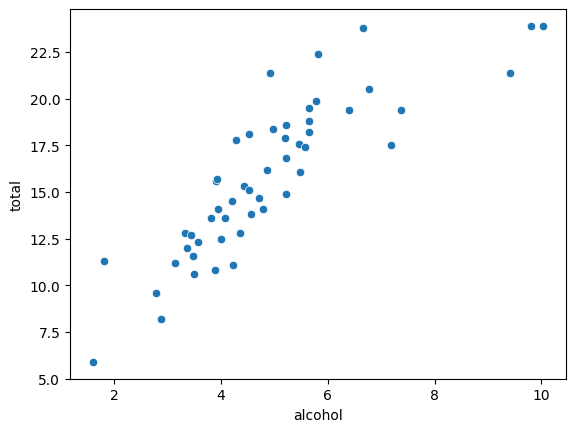

In [4]:
sns.scatterplot(x='alcohol',y='total',data=df)

In [5]:
#seleccionar todas las variables menos la variable uso_internet
variables_explicativas = df[['alcohol']]
variable_objetivo = df.total

# 5. Entrenar Modelo LinearRegression()

usar la función fit que entrena el modelo

In [6]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [7]:
type(model)

sklearn.linear_model._base.LinearRegression

In [10]:
model.fit(X=variables_explicativas, y=variable_objetivo)

LinearRegression()

In [12]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['alcohol'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([2.0325063]),
 'rank_': 1,
 'singular_': array([12.22681605]),
 'intercept_': 5.857776154826299}

$$
total =5.85 + 2.03 \cdot alcohol
$$

el modelo ya se ha calculado

# 6. Predecir Modelo

In [15]:
#predecir el modelo con 2 de alcohol
model.predict(X=[[2]])

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([9.92278876])

resultado 9.92

In [17]:
#mostrar las predicciones
model.predict(X=df[['alcohol']])

array([17.32111171, 15.05486718, 16.44306899, 17.69509287, 12.68699734,
       13.59756016, 13.76016066, 15.73575679,  9.0955587 , 16.40851638,
       13.78455074, 20.44100889, 14.87600663, 14.70324359, 14.40446516,
       13.8353634 , 14.54064309, 15.86177218, 19.6076813 , 15.06502971,
       13.98780137, 11.69106925, 13.88211104, 11.5162737 , 16.94713055,
       16.98371566, 24.99585551, 16.45729653, 15.41868581, 12.93089809,
       12.23171592, 15.95526747, 13.10772614, 16.44306899, 26.26007443,
       15.60161138, 17.58737003, 12.62195713, 17.32517672, 14.43088774,
       25.77430543, 18.86988151, 17.3515993 , 20.84141263,  9.53254755,
       14.15040187, 12.82724027, 12.96748321, 19.40239816, 15.11380986,
       17.17477126])

In [18]:
y_pred=model.predict(X=df[['alcohol']])

In [19]:
#insertar las predicciones en el dataframe
#insertar en la columna cero la columna pred con los valores de y_pred
df.insert(0,'pred',y_pred)

In [21]:
#visualizar dataframe
df.head()

,pred,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,17.321112,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,15.054867,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,16.443069,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,17.695093,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.686997,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


Si observas hay una leve diferencia entre la realidad y la predicción. En la fila 0, la predicción es de 17.32 y el total de accidentes es de 18.8

# 7. Visualizar modelo

<Axes: xlabel='alcohol', ylabel='total'>

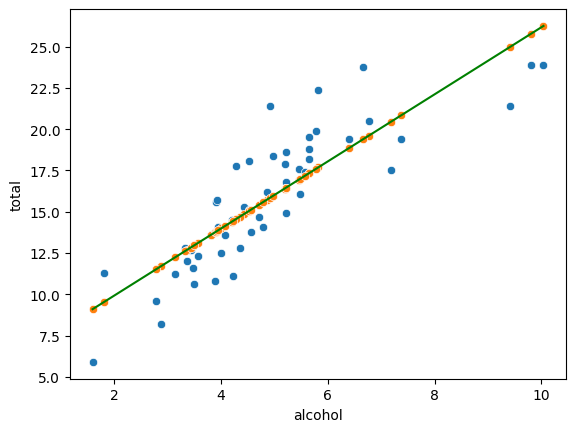

In [26]:
sns.scatterplot(x='alcohol',y='total',data=df)
#graficamos predicciones (color naranja)
sns.scatterplot(x='alcohol',y='pred',data=df)
#dibiujamos la linea recta
sns.lineplot(x='alcohol',y='pred',data=df, color='green')

# 8. Bondad de Ajuste

¿cuán bueno es el modelo?

In [27]:
model.score(X=variables_explicativas, y=variable_objetivo)

0.7269492966665405

Nuestro modelo explica un 72% de la variabilidad del total de accidentes